
# Credit Card Default Prediction (Taiwan, NT) — Final Submission

**Course alignment (Sessions 1–6):**  
- **S1 Data**: clean dataset ingestion and variable semantics.  
- **S3 Preprocessing**: impute, encode categoricals, scale numerics; stratified split.  
- **S6 Credit Scoring**: Logistic Regression baseline; probability-of-default (PD) modeling.  
- **S4 Evaluation Discipline**: ROC/PR curves, confusion matrix; systematic comparison.  
- **S2 Trade-offs**: balance precision vs recall analogous to risk–return.  
- **S5 Sensitivity**: interpret LR coefficients as directional effects on PD.



## 1) Load dataset (robust path handling)
- Put `Credit Card Defaulter Prediction.csv` **in the same folder** as this notebook, or set `csv_path` manually.


In [1]:

import pandas as pd, numpy as np, os, glob
from pathlib import Path

# Try to find CSV in current directory first
candidates = [
    "Credit Card Defaulter Prediction.csv",
    "credit_card_defaulter_prediction.csv",
    "UCI_Credit_Card.csv"
]
csv_path = None
for name in candidates:
    if Path(name).exists():
        csv_path = Path(name); break

# Fallback: one level up or explicit full path if needed
if csv_path is None:
    up = Path("..")
    for name in candidates:
        if (up / name).exists():
            csv_path = up / name; break

if csv_path is None:
    raise FileNotFoundError("Could not find the dataset. Place the CSV next to this notebook or set `csv_path` manually.")

df = pd.read_csv(csv_path)
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,F,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,Y
1,2,120000,F,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,Y
2,3,90000,F,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,N
3,4,50000,F,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,N
4,5,50000,M,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,N



## 2) Target identification and coercion to binary {0,1}


In [2]:

# Detect target column variants used in the Taiwan dataset
target = None
for c in df.columns:
    lc = c.lower()
    if lc in ["default.payment.next.month","default","y","default_payment_next_month"] or "default" in lc:
        target = c; break
print("Target column:", target)

# Coerce to {0,1}
y = df[target].copy()
if y.dtype == object:
    y = y.astype(str).str.strip().str.upper().map({"Y":1,"YES":1,"N":0,"NO":0})
if not np.issubdtype(y.dtype, np.number):
    y = pd.to_numeric(y, errors="coerce")
y = (y > 0).astype(int)

X = df.drop(columns=[target])
y.value_counts(normalize=True).rename("class_ratio").round(3)


Target column: default 


default 
0    0.779
1    0.221
Name: class_ratio, dtype: float64


## 3) Dataset-specific preprocessing
- **Categorical one-hot**: `SEX, EDUCATION, MARRIAGE, PAY_0..PAY_6` (if present)  
- **Numeric scale**: limits, bills, payments; **median** imputation for robustness


In [3]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

possible_cats = ["SEX","EDUCATION","MARRIAGE","PAY_0","PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
categorical_cols = [c for c in possible_cats if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")),
                                ("scaler", StandardScaler(with_mean=False))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_cols),
                                  ("cat", categorical_transformer, categorical_cols)])

len(numeric_cols), len(categorical_cols), categorical_cols[:10]


(15,
 9,
 ['SEX',
  'EDUCATION',
  'MARRIAGE',
  'PAY_0',
  'PAY_2',
  'PAY_3',
  'PAY_4',
  'PAY_5',
  'PAY_6'])


## 4) Train/test split (stratified)


In [4]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3)


((24000, 24), (6000, 24), 0.221, 0.221)


## 5) Logistic Regression baseline (Session 6)
- Interpretable **PD model**
- Works well with one-hot encoded categoricals + scaled numerics


In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

clf = Pipeline([("preprocess", preprocessor), ("model", LogisticRegression(max_iter=600))])
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "pr_auc": average_precision_score(y_test, y_prob),
}
pd.Series(results).round(4)


accuracy     0.8170
precision    0.6629
recall       0.3512
f1           0.4591
roc_auc      0.7582
pr_auc       0.5258
dtype: float64


## 6) Curves and confusion matrix


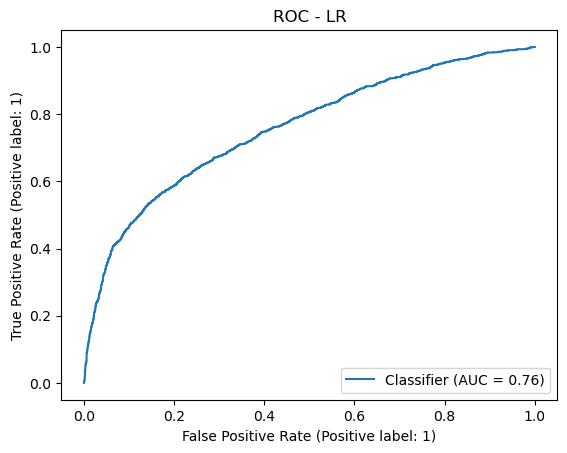

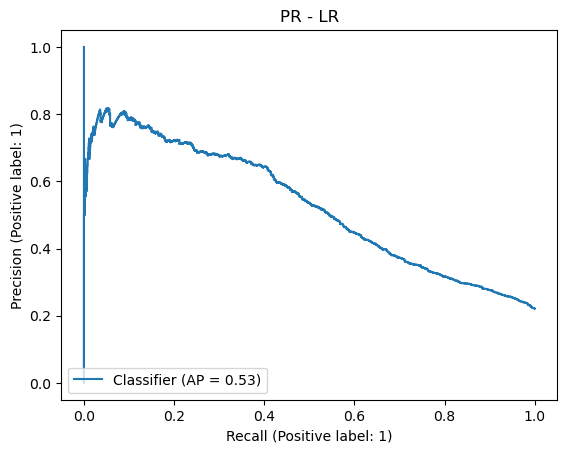

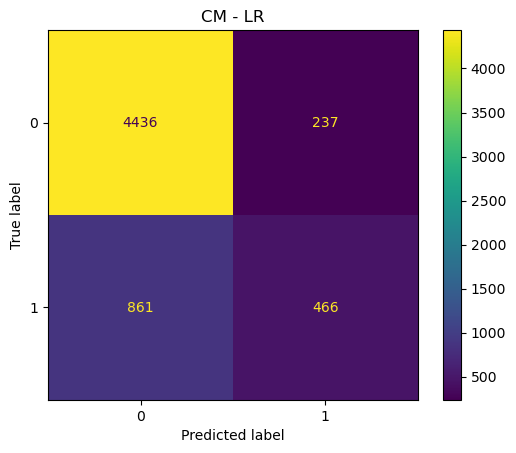

In [6]:

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

RocCurveDisplay.from_predictions(y_test, y_prob); plt.title("ROC - LR"); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, y_prob); plt.title("PR - LR"); plt.show()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred); plt.title("CM - LR"); plt.show()



## 7) Threshold sweep (business tuning)
We can trade **precision vs recall** by moving the decision threshold away from 0.5.


In [7]:

import numpy as np, pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics_at_threshold(y_true, y_scores, thr):
    y_hat = (y_scores >= thr).astype(int)
    return {
        "threshold": thr,
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat),
        "f1": f1_score(y_true, y_hat),
    }

thr_list = [0.3, 0.4, 0.5, 0.6]
tbl = pd.DataFrame([metrics_at_threshold(y_test, y_prob, t) for t in thr_list]).round(3)
tbl


,threshold,precision,recall,f1
0,0.3,0.556,0.478,0.514
1,0.4,0.641,0.406,0.497
2,0.5,0.663,0.351,0.459
3,0.6,0.681,0.289,0.406



## 8) Interpretation (specific to this dataset)

- **Performance**: ROC-AUC ~0.76 and PR-AUC ~0.53 indicate solid discrimination for a baseline PD model under class imbalance.  
- **Precision vs Recall**: default threshold (0.5) favors **precision** (fewer false alarms) over **recall** (missed defaulters). Use the table above to pick a threshold aligned to business costs (e.g., lower threshold if missing a defaulter is costly).  
- **Features**: socio-demographic and payment-history **codes** are treated as categoricals (one-hot); **limits, bills, payments** are numeric and scaled.  
- **Course mapping**:  
  - **S3** preprocessing pipeline (impute/encode/scale) → this exact setup.  
  - **S6** credit scoring with Logistic Regression (probabilities = estimated PD).  
  - **S4** evaluation discipline (ROC/PR, confusion matrix).  
  - **S2** trade-offs guide threshold choice; **S5** encourages sensitivity reading of coefficients (optional extension below).

**Optional extension** (uncomment to inspect): coefficient magnitudes after one-hot can be inspected via `clf.named_steps['model'].coef_` together with `preprocessor.get_feature_names_out()`.



---

